# This notebook was used to calibrate the seaweed-herbivore model

Required libraries: Plots, Statistics, DataFrames and CSV

Run the notebook top to bottom

## Libraries, Functions & Parameters

Libraries needed

In [1]:
using Plots
using Statistics
using DataFrames, CSV

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80](cache misses: target mismatch (1))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7](cache misses: target mismatch (1))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: target mismatch (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Tas

Functions

In [2]:
function laplacian(n)
  N = size(n, 1)
  lap = similar(n)

  for j in 1:N, i in 1:N
    ip = mod1(i+1, N)
    im = mod1(i-1, N)
    jp = mod1(j+1, N)
    jm = mod1(j-1, N)
    lap[i,j] = n[ip,j] + n[im,j] + n[i,jp] + n[i,jm] - 4*n[i,j]
  end

  return lap
end

function step(n,dt,omega,a,b,eps)
  lap = laplacian(n)
  dndt = omega.*n + a.*n.^2 - b.*n.^3 + eps*lap

  return n + dt*dndt
end

step (generic function with 1 method)

Project parameters

In [3]:
# Lattice
L = 500 #dm
ΔL = 1 #dm
N = Int(L/ΔL) #lattice units
dt = 0.1 # day

# Wet to Dry convertion
WW_to_DW = 0.1

# Crabs
σ = 10 #dm
α = 3.83*WW_to_DW #[gr DW crab⁻¹ day⁻¹]
μ = 3 #years
ρc = 0.01 #[crabs dm⁻²]

# Algae
ρa = 1 #[gr DW dm⁻²]

1

## Algae parameter ajutement

Net Primary Productivity (NPP)

Reading from the database the plant species with Genus Padina or Caulerpa (2º and 4º most eaten plant species)

(The other ones are not aviable)

In [5]:
df = CSV.read("NPP Dataset.csv", DataFrame)
df = filter(row -> row.Genus == "Padina" || row.Genus == "Caulerpa", df)

df.DW_Carbon_Conversion_factor[8] = "0.281"
df.DW_Carbon_Conversion_factor[9] = "0.281"
df.DW_Carbon_Conversion_factor = [parse(Float64, replace(string(x), ',' => '.')) for x in df.DW_Carbon_Conversion_factor]
df.Avg_NPP_kg_C_m2_y = [parse(Float64, replace(string(x), ',' => '.')) for x in df.Avg_NPP_kg_C_m2_y]
# Transforming Avg_NPP_kg_C_m2_y into Avg_NPP_g_DW_dm2_day
df.Avg_NPP_g_DW_dm2_day = df.Avg_NPP_kg_C_m2_y .* 1000 .* (1/100) .* (1/365) .* (1 ./ df.DW_Carbon_Conversion_factor)

21-element Vector{Float64}:
 0.000257490391933029
 6.575342465753425e-7
 0.00017464107686453577
 0.0009544766933028919
 1.4441966656047575e-6
 5.3128805175038056e-5
 0.004135101407914764
 0.0035587188612099642
 0.02195017793594306
 0.0038958904109589044
 0.0003835616438356165
 0.0006191780821917809
 0.000336986301369863
 0.006572602739726027
 0.004087671232876713
 0.00017835616438356168
 0.00012958904109589044
 4.345205479452055e-5
 0.0006985753424657536
 3.947869101978691e-7
 1.7123287671232877e-6

In [6]:
real_growth =  mean(df.Avg_NPP_g_DW_dm2_day)

0.00228732414441102

Fitting parameters with simulation of plant growth. The growth rate must match the average Dry Weigth net production per lattice (dm^2)

In [7]:
# Central start
N = 100 # Small grid
Central = zeros(N, N)
Central[N÷2-20:N÷2+20, N÷2-20:N÷2+20] .= 1.0

# Parameters
simulation_time = Int(3650*1) # 1 year
best_params = 0.0
best_eps = 0.0
best_error = Inf

# Grid search
scale = 0.055 # makes the average growth 0.0023 gr/day
eps_sweep = 0.01:0.01:0.20

omega = -0.4 * scale
a = 1.4 * scale
b = 1.0 * scale

for eps in eps_sweep
  n = copy(Central)
  instant_error = Float64[]

  for t in 1:simulation_time
    previous_n = copy(n)

    n = step(n,dt,omega,a,b,eps)

    # Choosing only the lattice untis actively growing
    frontier_mask = (n .> 0.001) #.& (n .< 0.99)
    num_growing_latices = sum(frontier_mask)
    growth_matrix = n .- previous_n

    if sum(n) == 0
      break
    end

    av_growth = sum(growth_matrix[frontier_mask])/num_growing_latices
    push!(instant_error, abs(av_growth - real_growth*dt))
  end

  # Best Parameter Selection
  model_error = mean(instant_error)

  if model_error < best_error
    best_eps = eps
    best_error = model_error
  end
end

println("Best epsilon found: ε = $best_eps")

Best epsilon found: ε = 0.07


Visual simulation of the fitted parameters

[ Info: Saved animation to /content/Fitted Parameters growth.gif


Plots.AnimatedGif("/content/Fitted Parameters growth.gif")
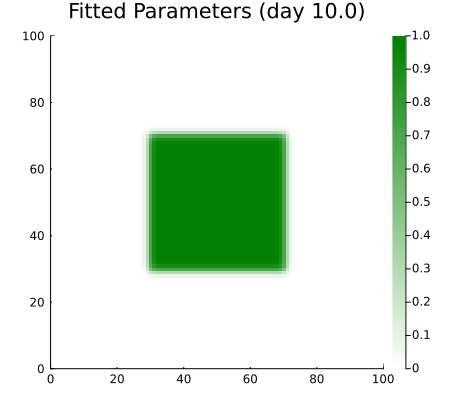

In [8]:
anim = Animation()

# Central start
N = 100 # Small grid
Central = zeros(N, N)
Central[N÷2-20:N÷2+20, N÷2-20:N÷2+20] .= 1.0
n = copy(Central)

# Parameters
simulation_time = Int(3650*3) # 3 years
scale = 0.055
omega = -0.4 * scale
a = 1.4 * scale
b = 1.0 * scale
eps = 0.07

for i in 1:simulation_time
  n = step(n,dt,omega,a,b,eps)

  if i % 100 == 0
    p = heatmap(n,
      aspect_ratio=:equal,
      grid=false,
      color = cgrad([:white, :green]),
      clims=(0.0, 1),
      xlims=(0,N),
      ylims=(0,N),
      title="Fitted Parameters (day $(round(i*dt, digits=0)))",
      size=(450,400)
    )
    frame(anim, p)
  end
end

gif(anim, "Fitted Parameters growth.gif", fps=10)